In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(
    "employee_salary_dataset_records.csv"
)

df.head()

,Age,Education,Experience,JobRole,WorkingHours,Salary
0,59,Bachelor,35,Data Scientist,44,218709.69
1,49,Master,26,Data Scientist,35,184042.76
2,35,High School,13,Data Scientist,51,105870.24
3,28,Bachelor,5,Accountant,46,83068.35
4,41,High School,14,Accountant,59,114634.93


In [5]:
print("Rows and Columns")

print(df.shape)

print("\nColumns")

print(df.columns)

print("\nInformation")

df.info()

Rows and Columns
(200, 6)

Columns
Index(['Age', 'Education', 'Experience', 'JobRole', 'WorkingHours', 'Salary'], dtype='str')

Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           200 non-null    int64  
 1   Education     200 non-null    str    
 2   Experience    200 non-null    int64  
 3   JobRole       200 non-null    str    
 4   WorkingHours  200 non-null    int64  
 5   Salary        200 non-null    float64
dtypes: float64(1), int64(3), str(2)
memory usage: 9.5 KB


In [6]:
df.describe()

,Age,Experience,WorkingHours,Salary
count,200.000000,200.000000,200.000000,200.000000
mean,40.045000,15.480000,43.525000,130840.217800
std,11.826339,11.419352,9.374368,54239.184616
min,21.000000,0.000000,30.000000,30045.120000
25%,29.000000,5.000000,35.000000,84989.027500
50%,41.500000,15.000000,42.500000,126743.660000
75%,50.000000,25.250000,52.000000,179395.265000
max,59.000000,35.000000,60.000000,242652.600000


In [7]:
df.isnull().sum()

Age             0
Education       0
Experience      0
JobRole         0
WorkingHours    0
Salary          0
dtype: int64

In [8]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [9]:
df.drop_duplicates(
    inplace=True
)

print(
    "Duplicates Removed Successfully"
)

Duplicates Removed Successfully


In [10]:
df.dtypes

Age               int64
Education           str
Experience        int64
JobRole             str
WorkingHours      int64
Salary          float64
dtype: object

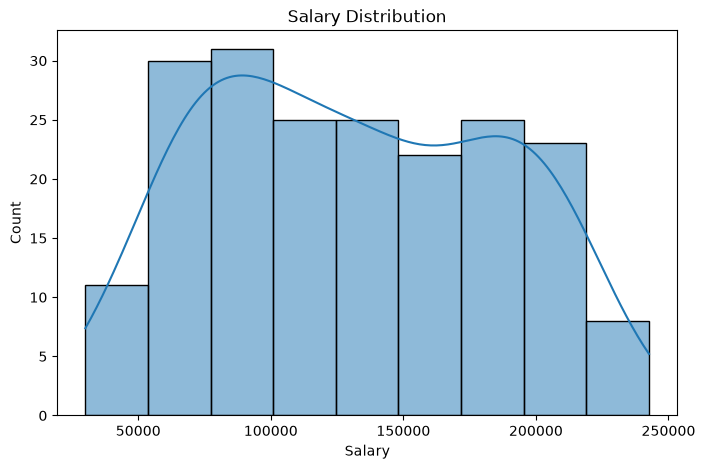

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Salary"],
    kde=True
)

plt.title(
    "Salary Distribution"
)

plt.show()

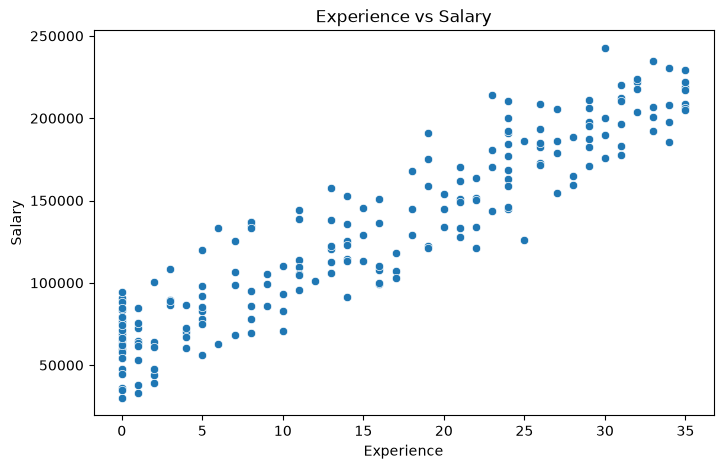

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Experience",
    y="Salary",
    data=df
)

plt.title(
    "Experience vs Salary"
)

plt.show()

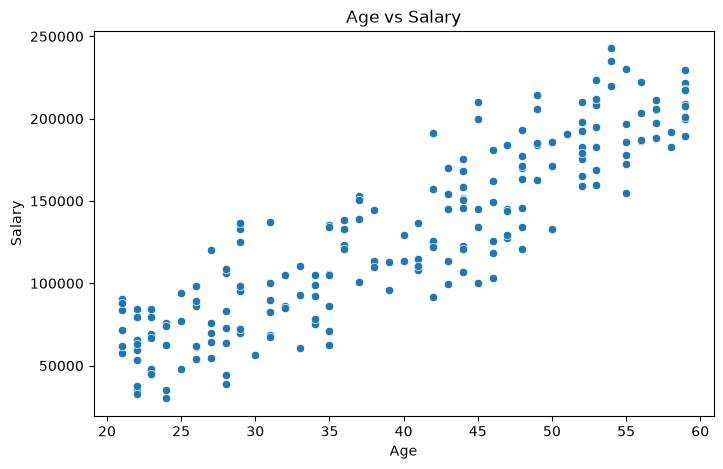

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Salary",
    data=df
)

plt.title(
    "Age vs Salary"
)

plt.show()

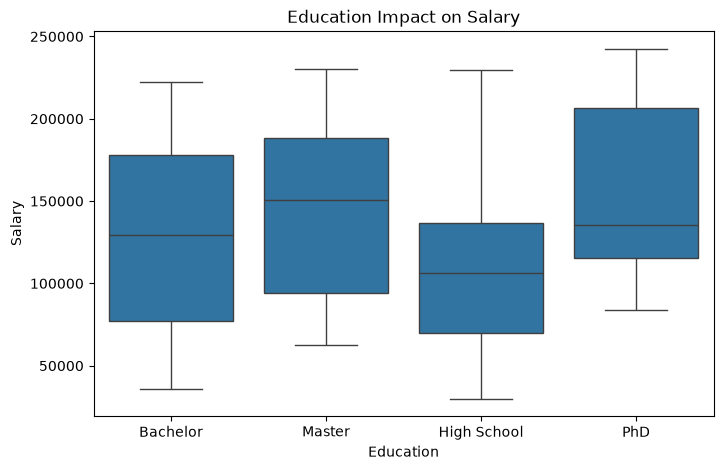

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Education",
    y="Salary",
    data=df
)

plt.title(
    "Education Impact on Salary"
)

plt.show()

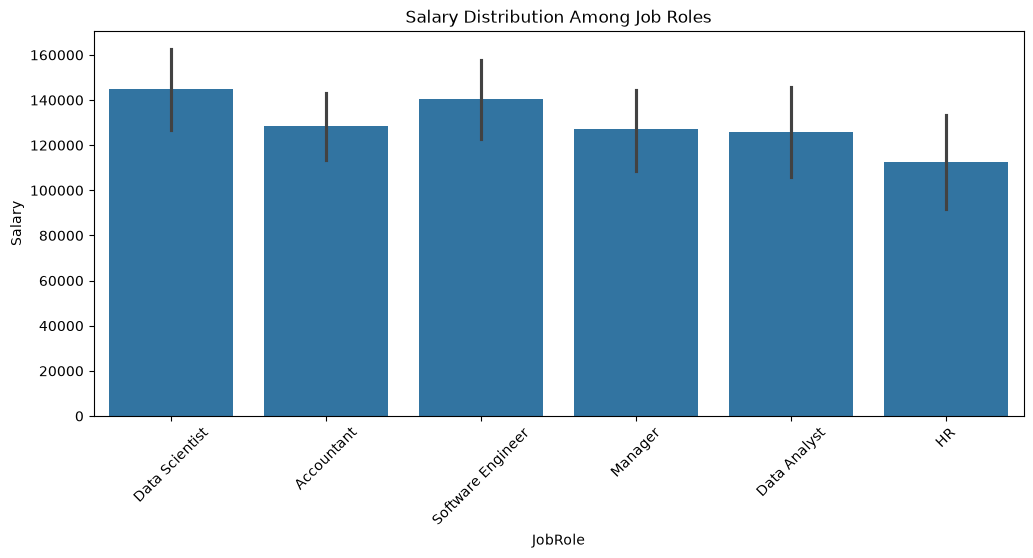

In [15]:
plt.figure(figsize=(12,5))

sns.barplot(
    x="JobRole",
    y="Salary",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Salary Distribution Among Job Roles"
)

plt.show()

In [16]:
highest = df.groupby(
    "JobRole"
)["Salary"].mean()

highest.sort_values(
    ascending=False
)

JobRole
Data Scientist       145081.041316
Software Engineer    140470.334857
Accountant           128533.354615
Manager              126983.675357
Data Analyst         125858.591290
HR                   112708.351724
Name: Salary, dtype: float64

In [17]:
role_salary = df.groupby(
    "JobRole"
)["Salary"].mean()

print(
    "Highest Paying Position:"
)

print(
    role_salary.idxmax()
)

print(
    role_salary.max()
)

print("\nLowest Paying Position:")

print(
    role_salary.idxmin()
)

print(
    role_salary.min()
)

Highest Paying Position:
Data Scientist
145081.04131578948

Lowest Paying Position:
HR
112708.35172413793


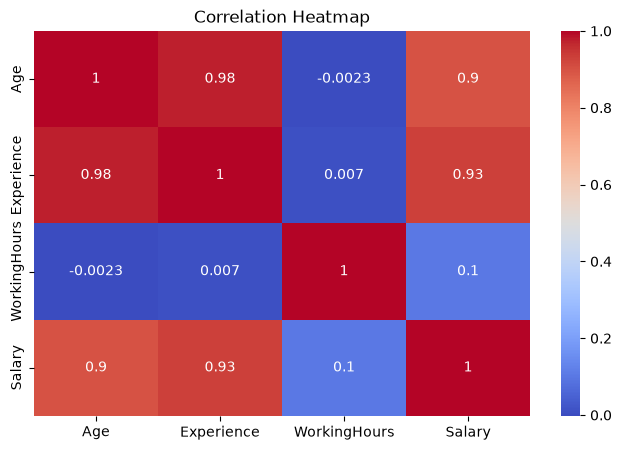

In [18]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [19]:
bins = [0,5,10,15,20,40]

labels = [
    "0-5",
    "6-10",
    "11-15",
    "16-20",
    "20+"
]

df["ExperienceGroup"] = pd.cut(
    df["Experience"],
    bins=bins,
    labels=labels
)

df.groupby(
    "ExperienceGroup"
)["Salary"].mean()

ExperienceGroup
0-5       72544.094687
6-10     100596.260000
11-15    121484.040000
16-20    133887.658500
20+      185848.017949
Name: Salary, dtype: float64

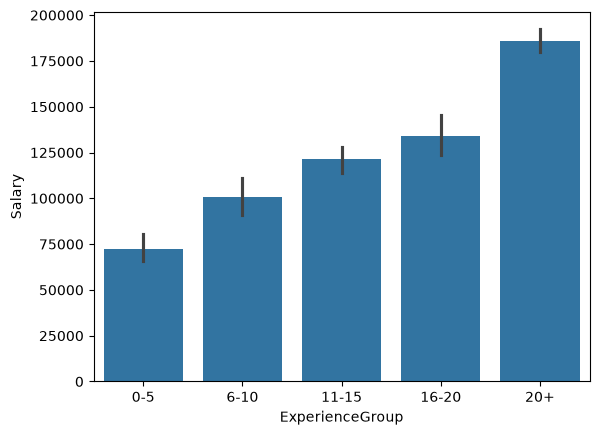

In [20]:
sns.barplot(
    x="ExperienceGroup",
    y="Salary",
    data=df
)

plt.show()

In [21]:
education_encoder = LabelEncoder()
job_encoder = LabelEncoder()

df["Education"] = (
    education_encoder.fit_transform(
        df["Education"]
    )
)

df["JobRole"] = (
    job_encoder.fit_transform(
        df["JobRole"]
    )
)

df.head()

,Age,Education,Experience,JobRole,WorkingHours,Salary,ExperienceGroup
0,59,0,35,2,44,218709.69,20+
1,49,2,26,2,35,184042.76,20+
2,35,1,13,2,51,105870.24,11-15
3,28,0,5,0,46,83068.35,0-5
4,41,1,14,0,59,114634.93,11-15


In [23]:
X = df.drop(
    ["Salary","ExperienceGroup"],
    axis=1
)

y = df["Salary"]

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

In [26]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

In [27]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [28]:
def evaluate_model(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return mae,mse,rmse,r2

In [29]:
lr_result = evaluate_model(
    y_test,
    lr_pred
)

dt_result = evaluate_model(
    y_test,
    dt_pred
)

rf_result = evaluate_model(
    y_test,
    rf_pred
)

In [30]:
comparison = pd.DataFrame({

"Model":[
    "Linear Regression",
    "Decision Tree",
    "Random Forest"
],

"MAE":[
    lr_result[0],
    dt_result[0],
    rf_result[0]
],

"MSE":[
    lr_result[1],
    dt_result[1],
    rf_result[1]
],

"RMSE":[
    lr_result[2],
    dt_result[2],
    rf_result[2]
],

"R2 Score":[
    lr_result[3],
    dt_result[3],
    rf_result[3]
]

})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,12898.190316,2.671397e+08,16344.408858,0.904586
1,Decision Tree,20159.190250,5.539133e+08,23535.362203,0.802160
2,Random Forest,11119.265733,1.771809e+08,13310.931332,0.936717


In [31]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,11119.265733,1.771809e+08,13310.931332,0.936717
0,Linear Regression,12898.190316,2.671397e+08,16344.408858,0.904586
1,Decision Tree,20159.190250,5.539133e+08,23535.362203,0.802160


In [32]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":
rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Experience,0.842357
0,Age,0.065577
1,Education,0.055595
4,WorkingHours,0.022013
3,JobRole,0.014458


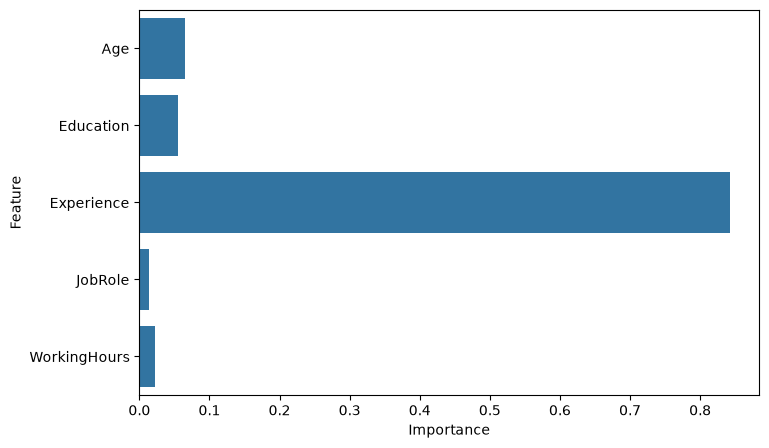

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()

In [34]:
joblib.dump(
    rf,
    "salary_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [35]:
sample_employee = [[

30,
1,
5,
2,
45

]]

prediction = rf.predict(
    sample_employee
)

print(
    "Predicted Salary:",
    prediction[0]
)

Predicted Salary: 75578.84124999992


In [39]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

model = joblib.load("salary_model.pkl")

st.set_page_config(
    page_title="Employee Salary Prediction",
    page_icon="💰",
    layout="centered"
)

st.title("💰 Employee Salary Prediction System")

st.write(
    "Enter employee details to predict salary."
)

age = st.number_input(
    "Age",
    min_value=18,
    max_value=65,
    value=30
)

education = st.selectbox(
    "Education Level",
    ["High School","Bachelor","Master","PhD"]
)

experience = st.number_input(
    "Years of Experience",
    min_value=0,
    max_value=40,
    value=5
)

job_role = st.selectbox(
    "Job Role",
    [
        "Accountant",
        "Data Analyst",
        "Data Scientist",
        "HR",
        "Manager",
        "Software Engineer"
    ]
)

working_hours = st.number_input(
    "Working Hours Per Week",
    min_value=20,
    max_value=80,
    value=40
)

education_mapping = {
    "Bachelor":0,
    "High School":1,
    "Master":2,
    "PhD":3
}

job_mapping = {
    "Accountant":0,
    "Data Analyst":1,
    "Data Scientist":2,
    "HR":3,
    "Manager":4,
    "Software Engineer":5
}

if st.button("Predict Salary"):

    input_data = np.array([[
        age,
        education_mapping[education],
        experience,
        job_mapping[job_role],
        working_hours
    ]])

    prediction = model.predict(input_data)

    st.success(
        f"Predicted Salary: ${prediction[0]:,.2f}"
    )

    st.subheader("AI Insights")

    if experience < 5:
        st.info(
            "Increasing experience can significantly improve salary."
        )

    if education in ["High School","Bachelor"]:
        st.info(
            "Obtaining a Master's degree may increase earning potential."
        )

    st.info(
        "Recommended Skills: Python, SQL, Power BI, Machine Learning"
    )

2026-06-26 00:19:53.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 00:19:53.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [36]:
def ai_insights(
    salary,
    experience,
    education
):

    print(
        "AI Salary Insights"
    )

    print(
        f"Expected Salary: {salary:.2f}"
    )

    if experience < 5:
        print(
            "Gain more experience for higher salary."
        )

    if education < 2:
        print(
            "Consider Master's degree."
        )

    print(
        "Recommended Skills:"
    )

    print(
        "- Python"
    )

    print(
        "- SQL"
    )

    print(
        "- Machine Learning"
    )

    print(
        "- Power BI"
    )

ai_insights(
    prediction[0],
    5,
    1
)

AI Salary Insights
Expected Salary: 75578.84
Consider Master's degree.
Recommended Skills:
- Python
- SQL
- Machine Learning
- Power BI
